In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
# from scipy.io import readsav
# from pathlib import Path
import maos_utils as mu
from scipy import signal
# from astropy.io import fits
from PyAstronomy import pyasl

In [2]:
def sci_format(x, lim):
    return '{:.8e}'.format(x)

In [3]:
def rms_wfe_KAON113(wvl, r0, SNR, theta_gs=1.93, ctrlloop=0.393, d=0.5625):
    ( ( wvl / ( (8 / (3*np.pi)) * ( np.exp(-0.115 * (d/r0)) + np.exp(-0.155 * (d/r0)**2.0) ) ) ) + ( ( np.pi*d*theta_gs ) / 8.0 ) ) * (ctrlloop/SNR)
    return

##### This telemetry file corresponds to science image ``i240807_a047047.fits``, which has a Strehl of 0.297, FWHM of 60.16 mas, and an RMS WFE of 371.8 nm, according to ``strehl_source.txt`` in directory ``/g/lu/data/microlens/24aug07os/clean/ob230215_kp_tdOpen``. As a result we can say this was a fair/good quality image (not great), so we expect similar signs within the telemetry below of good quality. Based on directory name, the object under observation in this science image is OB230215. From Macy Houston, this is microlensing object OGLE-2023-BLG-0215

In [ ]:
# Convert magnitude to flux density based on Bessel et al. 1998
mag_I = 19.4 # from https://ogle.astrouw.edu.pl/ogle4/ews/2023/blg-0215.html
fd_nu, le = pyasl.magToFluxDensity_bessel98("I", mag_I, "nu")
print("I-band magnitude: ", mag_I)
print("I-band flux density [erg/cm**2/s/Hz]: ", fd_nu)

I-band magnitude:  19.4
I-band flux density [erg/cm**2/s/Hz]:  4.199523346640699e-28


In [5]:
# Dark current formula for CCD-39 SHWFS from KAON 387
def Qd(T):
    Qd0 = 109243
    return 122.0 * T**3.0 * np.exp(-6400.0/T) * Qd0

#### **Load in telemetry**

##### **Down tip/tilt**

In [6]:
root = '/g/lu/data/keck_telemetry/20240807'
down_tt = f'{root}/LGS-downtiptilt-2024-08-07T06:59:33-2024-08-07T07:00:03.npz' #08-06-2024 (date in file is hst, time is utc)

In [7]:
down_tt_telemetry = np.load(down_tt)

In [8]:
print(list(down_tt_telemetry.keys()))

['rawtimestamp', 'timestamp', 'frameCounter', 'TTslope', 'DTTMirrorCommand']


In [9]:
down_tt_telemetry.files

['rawtimestamp', 'timestamp', 'frameCounter', 'TTslope', 'DTTMirrorCommand']

In [10]:
down_tt_telemetry['rawtimestamp']

array([1.72301397e+18, 1.72301397e+18, 1.72301397e+18, ...,
       1.72301401e+18, 1.72301401e+18, 1.72301401e+18])

In [11]:
down_tt_centroids_x = down_tt_telemetry['TTslope'][:,0]
down_tt_centroids_y = down_tt_telemetry['TTslope'][:,1]

##### **Up Tip/tilt**

In [12]:
up_tt = f'{root}/LGS-uptiptilt-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
up_tt_telemetry = np.load(up_tt)

In [13]:
up_tt_telemetry.files

['rawtimestamp',
 'timestamp',
 'frameCounter',
 'SHWFS1TT',
 'UTTMainMirrorCommand']

In [14]:
up_tt_x = up_tt_telemetry['SHWFS1TT'][:,0]
up_tt_y = up_tt_telemetry['SHWFS1TT'][:,1]

##### **STRAP**

In [15]:
strap = f'{root}/LGS-straprtc-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
strap_telemetry = np.load(strap)

In [16]:
strap_telemetry.files

['rawtimestamp', 'timestamp', 'frameCounter', 'STRAPImage', 'STRAPCentroid']

In [17]:
(np.max(strap_telemetry['rawtimestamp']) - np.min(strap_telemetry['rawtimestamp'])) / (1e9)

39.996333312

In [18]:
strap_telemetry['STRAPCentroid']

array([[-0.03740734, -0.02674329],
       [ 0.05046558, -0.1793732 ],
       [ 0.12388635, -0.13989264],
       ...,
       [-0.12850273, -0.0136981 ],
       [-0.05743295, -0.0157221 ],
       [-0.0374859 , -0.04811567]])

In [19]:
strap_telemetry['STRAPImage']

array([[ 95., 127., 116.,  86.],
       [ 88., 121.,  80.,  73.],
       [ 68., 131.,  87.,  67.],
       ...,
       [ 80., 104., 105.,  64.],
       [ 76., 125., 118.,  67.],
       [ 87., 110.,  96.,  77.]])

##### **OCAM2K**

In [20]:
ocam2k = f'{root}/LGS-ocam2k-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
ocam2k_telemetry = np.load(ocam2k)

In [21]:
ocam2k_telemetry.files

['rawtimestamp',
 'timestamp',
 'frameCounter',
 'SHWFS1Centroid',
 'SHWFS1SubAper']

In [22]:
ocam2k_telemetry['SHWFS1SubAper'].shape

(30000, 304)

##### **Xinetics**

In [23]:
xinetics = f'{root}/LGS-xinetics-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
xinetics_telemetry = np.load(xinetics)

In [24]:
xinetics_telemetry.files

['rawtimestamp', 'timestamp', 'frameCounter', 'residualWaveFront', 'DMCommand']

In [25]:
xinetics_telemetry['residualWaveFront']

array([[ 7.24015713,  3.48153567,  2.73270988, ..., -0.07795916,
         0.17388219,  1.49046731],
       [ 7.64563847,  4.18183565,  3.12334394, ...,  0.24793935,
         0.01165447,  1.48592114],
       [ 8.3049736 ,  4.78770065,  3.16448212, ..., -0.13764608,
         0.12277693,  2.49442339],
       ...,
       [ 7.45466709,  4.129179  ,  2.52962208, ...,  0.48750174,
         0.86794615,  2.77267623],
       [ 7.96255207,  4.62483978,  2.85610604, ..., -0.13283551,
         0.14456391,  2.40308714],
       [ 8.83214569,  5.44389629,  2.97767448, ...,  0.84243381,
         0.9251591 ,  2.84610343]])

##### **Strain Gauge**

In [26]:
gauge = f'{root}/LGS-clmpstraingauge-2024-08-07T06:59:33-2024-08-07T07:00:03.npz'
clmpstraingauge = np.load(gauge)

In [27]:
clmpstraingauge.files

['rawtimestamp',
 'timestamp',
 'frameCounter',
 'DTTStrainGauge',
 'UTTMainStrainGauge']

In [28]:
clmpstraingauge['UTTMainStrainGauge'].shape

(30000, 2)

##### **Raw SHWFS**

In [29]:
shwfs_raw = f'{root}/LGS-SHWFSraw-2024-08-07T06:59:33.007755-2024-08-07T06:59:42.998621.npz'
shwfs_raw_telemetry = np.load(shwfs_raw)

In [30]:
shwfs_raw_telemetry.files

['rawtimestamp', 'timestamp', 'SHWFS1Image']

In [31]:
shwfs_raw_telemetry['SHWFS1Image'].shape

(1000, 1600)

#### **Compare STRAP and SHWFS intensities over time**

Check for cloud cover + compute STRAP WFE using centroid timestream

In [32]:
print(strap_telemetry['frameCounter'])
print(strap_telemetry['STRAPImage'])

[23877912. 23877913. 23877914. ... 23887909. 23887910. 23887911.]
[[ 95. 127. 116.  86.]
 [ 88. 121.  80.  73.]
 [ 68. 131.  87.  67.]
 ...
 [ 80. 104. 105.  64.]
 [ 76. 125. 118.  67.]
 [ 87. 110.  96.  77.]]


In [33]:
apd_channels = strap_telemetry['STRAPImage']*0.3
apd_avg_over_time = np.mean(apd_channels, axis=0)
print(apd_avg_over_time.shape)
print(np.sum(apd_avg_over_time))
# Choose a sub aperture to plot timestream intensity
sample_subaper = ocam2k_telemetry['SHWFS1SubAper']

(4,)
112.15355999999994


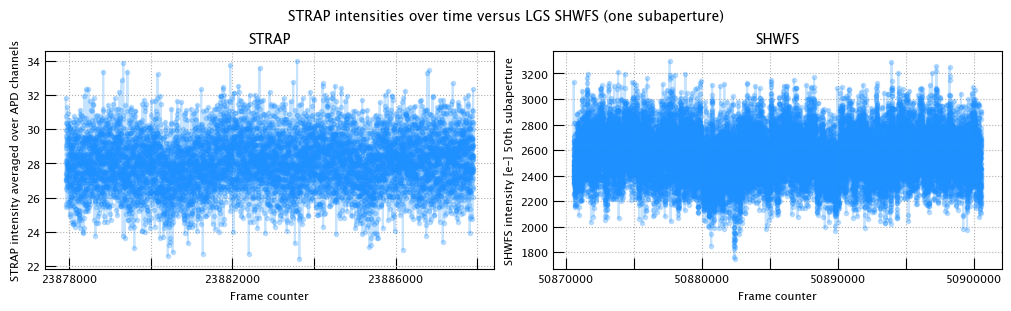

In [34]:
apd_channels = strap_telemetry['STRAPImage']
apd_avg = np.mean(apd_channels, axis=1)
# Choose a sub aperture to plot timestream intensity
sample_subaper = ocam2k_telemetry['SHWFS1SubAper']

fig = plt.figure(figsize=(10.0, 3.0), layout='constrained')
spec = fig.add_gridspec(1, 2)
fig.suptitle(f"STRAP intensities over time versus LGS SHWFS (one subaperture)", fontsize=10.0)
ax0 = fig.add_subplot(spec[0,0])
ax1 = fig.add_subplot(spec[0,1])
ax0.plot(strap_telemetry['frameCounter'], apd_avg*0.3, '.-', alpha=0.25, color='dodgerblue') # multiply by gain of 0.3
ax1.plot(ocam2k_telemetry['frameCounter'], sample_subaper[:,50]*0.508, '.-', alpha=0.25, color='dodgerblue') # multiply by gain to go from ADU to e-
ax0.set_title("STRAP", fontsize=10.0)
ax1.set_title("SHWFS", fontsize=10.0)
ax0.set_ylabel("STRAP intensity averaged over APD channels", fontsize=8.0)
ax1.set_ylabel("SHWFS intensity [e-] 50th subaperture", fontsize=8.0)
ax0.set_xlabel("Frame counter", fontsize=8.0)
ax1.set_xlabel("Frame counter", fontsize=8.0)
ax0.grid(True, linestyle='dotted')
ax1.grid(True, linestyle='dotted')
ax0.tick_params(axis='both', direction='in', labelsize=8.0)
ax1.tick_params(axis='both', direction='in', labelsize=8.0)
# ax0.xaxis.set_major_formatter(FuncFormatter(sci_format))
# ax1.xaxis.set_major_formatter(FuncFormatter(sci_format))
ax0.ticklabel_format(useOffset=False, style='plain')
ax1.ticklabel_format(useOffset=False, style='plain')
for label in ax0.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
for label in ax1.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)

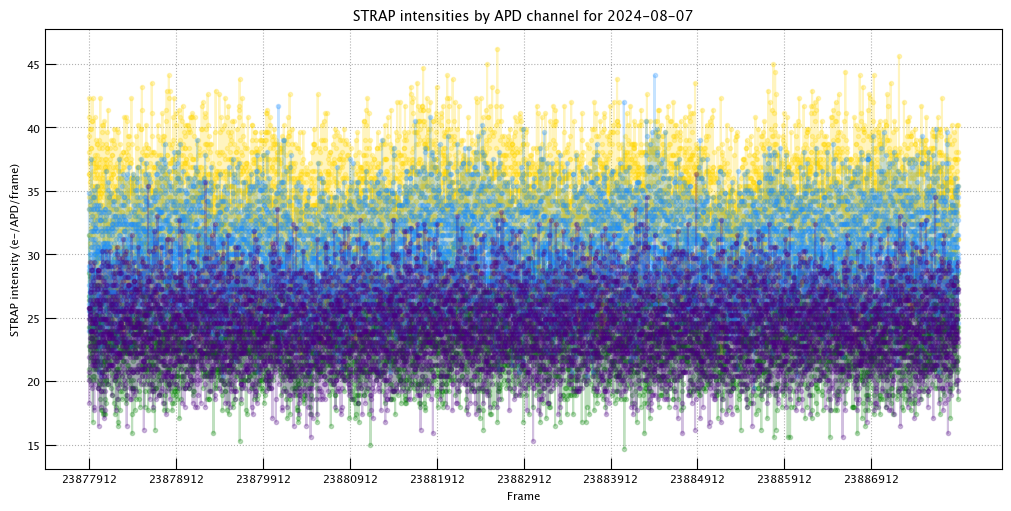

In [35]:
fig = plt.figure(figsize=(10.0, 5.0), layout='constrained')
# Multiply by highest gain STRAP can be (0.3) - multiplying by lower gains decrease intensities further
plt.plot(strap_telemetry['frameCounter'], strap_telemetry['STRAPImage'][:,0]*0.3, '.-', alpha=0.25, color='green')
plt.plot(strap_telemetry['frameCounter'], strap_telemetry['STRAPImage'][:,1]*0.3, '.-', alpha=0.25, color='gold')
plt.plot(strap_telemetry['frameCounter'], strap_telemetry['STRAPImage'][:,2]*0.3, '.-', alpha=0.25, color='dodgerblue')
plt.plot(strap_telemetry['frameCounter'], strap_telemetry['STRAPImage'][:,3]*0.3, '.-', alpha=0.25, color='indigo')
plt.grid(True, linestyle='dotted')
# plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
# for label in plt.gca().xaxis.get_ticklabels()[::2]:
#     label.set_visible(False)
plt.xticks(np.arange(min(strap_telemetry['frameCounter']), max(strap_telemetry['frameCounter'])+1, 1000.0))
plt.gca().ticklabel_format(useOffset=False, style='plain')
plt.gca().tick_params(axis='x', which='minor', bottom=True)
plt.xlabel("Frame", fontsize=8.0)
plt.ylabel("STRAP intensity (e-/APD/frame)", fontsize=8.0)
plt.title("STRAP intensities by APD channel for 2024-08-07", fontsize=10.0)
plt.gca().tick_params(axis='both', direction='in', labelsize=8.0)

##### **STRAP WFE computation**

In [36]:
np.mean(np.diff(strap_telemetry['rawtimestamp']))*(1e-6) # convert from ns to ms

4.0000333345334536

In [37]:
tip_centroids = strap_telemetry['STRAPCentroid'][:,0] # arcseconds 
tilt_centroids = strap_telemetry['STRAPCentroid'][:,1] # arcseconds
# print(tilt_centroids)
# RMS
rms_tip = np.sqrt(np.mean(pow(tip_centroids, 2))) # pyAO rms function calculation method
rms_tilt = np.sqrt(np.mean(pow(tilt_centroids, 2))) # pyAO rms function calculation method
print(f"RMS tip error = {rms_tip} arcsec | RMS tilt error = {rms_tilt} arcsec")
# Conversion factor from van Dam Performance of the Keck Observatory AO system
conv = 12.68 # microns per arcsec
rms_tip *= conv*(1000.0) # microns to nm
rms_tilt *= conv*(1000.0) # microns to nm
print(f"RMS tip error = {rms_tip} nm | RMS tilt error = {rms_tilt} nm")
# # From Lianqi conversion factor: 1 radian of tip/tilt gives R/2 m RMS OPD error
# opd_tip = ( rms_tip * ( np.pi / (180.0 * 3600.0) ) ) * (11.0 / 2.0) # meters
# # opd_tip *= (1e9) # meters to nm
# print(opd_tip)

RMS tip error = 0.07901127606551725 arcsec | RMS tilt error = 0.07684578818742391 arcsec
RMS tip error = 1001.8629805107587 nm | RMS tilt error = 974.4045942165352 nm


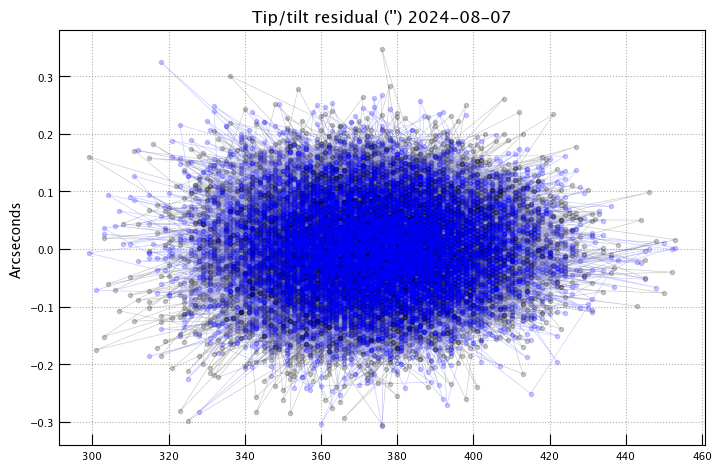

In [38]:
# Plot STRAP centroids as function of signal level to match K. Avicola paper plot (Figure 12)
plt.figure(figsize=(7.5, 5.0))
# Compute signal level (total of four quadrants/APD channels) - Avicola paper has this is e-/sec but STRAP gain is unknown so I will keep as ADU
all_apd_signal = np.sum(strap_telemetry['STRAPImage'], axis=1)
plt.plot(all_apd_signal, tip_centroids, 'k.-', linewidth=0.5, alpha=0.2)
plt.plot(all_apd_signal, tilt_centroids, 'b.-', linewidth=0.5, alpha=0.2)
plt.title("Tip/tilt residual (\'\') 2024-08-07", fontsize=12.0)
plt.ylabel("Arcseconds", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")
plt.grid(True, linestyle='dotted')
plt.tight_layout()

#### **STRAP Spot size ($\theta_{\beta}$): ``maos_utils.keck_nea_photons()`` calculation versus telemetry-derived result**

In [39]:
arcsec_to_rad = np.pi / (180.0 * 3600.0)
rad_to_arcsec = (180.0 * 3600.0) / np.pi

# Equation 5 from Atmospheric turbulence characterization with the Keck adaptive optics systems. I. Open-loop data
# refer to Figure 1 for quad cell numbering convention used in cx equation below. 
# Mapping to Claire Max's (https://www.ucolick.org/~max/289/Lectures%202020/Lecture%208%20-%20Wavefront%20Sensing/Lecture8_2020_v1_sm.pdf)
# version, I1 = I5, I2 = I8, I4 = I4, and I3 = I7 (Claire Max numbers first)
# cx = (I5 + I8 - (I4 + I7)) / (I4 + I5 + I7 + I8)

I7 = strap_telemetry['STRAPImage'][:,0]
I8 = strap_telemetry['STRAPImage'][:,1]
I4 = strap_telemetry['STRAPImage'][:,2]
I5 = strap_telemetry['STRAPImage'][:,3]
diff_over_sum_I = ( I8 + I5 - (I7 + I4) ) / (I4 + I5 + I7 + I8)
b_from_tip = ( tip_centroids * 2.0) / diff_over_sum_I

/var/folders/3r/l23jlh4s1hdfwp43nrrhx1xm00012l/T/ipykernel_30161/194828385.py:15: RuntimeWarning: divide by zero encountered in divide
  b_from_tip = ( tip_centroids * 2.0) / diff_over_sum_I


45.89087426662445


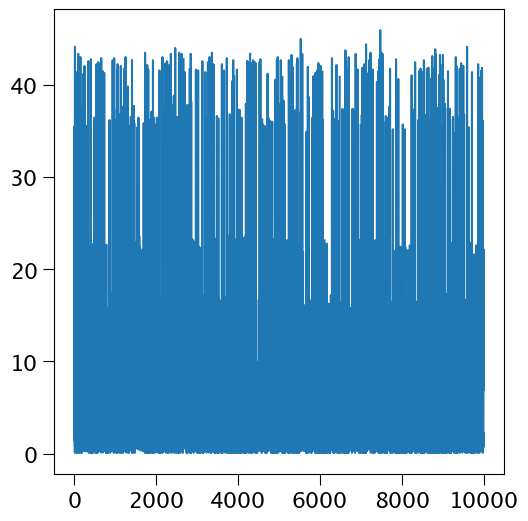

In [40]:
print(np.max(np.abs(np.ma.masked_invalid(b_from_tip))))
plt.plot(np.abs(np.ma.masked_invalid(b_from_tip)))

#### **STRAP SNR from telemetry**

In [41]:
# Standard deviation
strap_sigma_from_tip = np.std(np.abs(tip_centroids), axis=0)
strap_sigma_from_tilt = np.std(np.abs(tilt_centroids), axis=0)
# SNR = theta (spot size) / sigma_arcsec
# Spot size in arcseconds - 0.898'' according to calculation in keck_nea_photons_validation.ipynb
spot = 0.898
STRAP_SNR_KAON422_tip = spot / strap_sigma_from_tip
STRAP_SNR_KAON422_tilt = spot / strap_sigma_from_tilt
print(STRAP_SNR_KAON422_tip)
print(STRAP_SNR_KAON422_tilt)
print(np.mean([STRAP_SNR_KAON422_tip, STRAP_SNR_KAON422_tilt]))

18.813519992941213
19.255506478256567
19.03451323559889


#### **Higher-order RMS WFE**

In [42]:
ho_rms_wfe = np.sqrt(np.mean(np.square(xinetics_telemetry['residualWaveFront'][:,50:56])))
ho_rms_wfe *= (0.6 * 1000.0) # 0.6 microns/volts, then * 1000.0 for microns to nm
# Average over time
avg_ho_rms_wfe = np.mean(ho_rms_wfe)
print(f"Time-averaged higher-order RMS WFE from telemetry residualWaveFront = {avg_ho_rms_wfe} nm")

Time-averaged higher-order RMS WFE from telemetry residualWaveFront = 220.62364127970721 nm


#### **Plot tip/tilt residuals (centroids, slopes) in X and Y**

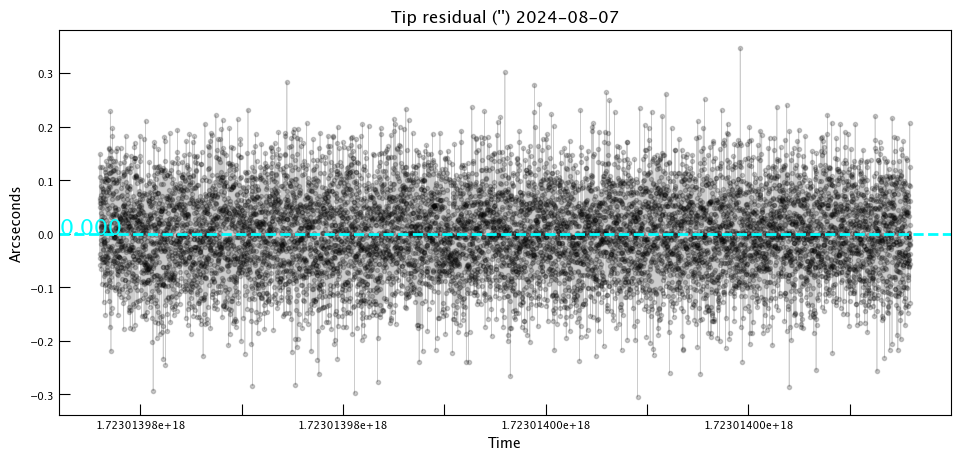

In [43]:
plt.figure(figsize=(10.0, 5.0))
plt.plot(strap_telemetry['rawtimestamp'], tip_centroids, 'k.-', linewidth=0.5, alpha=0.2)
plt.axhline(y=np.mean(tip_centroids), color='cyan', linestyle='--', linewidth=2, 
            label=r"$\bar{\mathtt{residual tip}}$ arcsec")
plt.text(plt.xlim()[0], np.mean(tip_centroids)*1.03, s=f"{np.mean(tip_centroids):.3f}", color='cyan')
plt.title("Tip residual (\'\') 2024-08-07", fontsize=12.0)
plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
plt.ylabel("Arcseconds", fontsize=10.0)
for label in plt.gca().xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xlabel("Time", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")

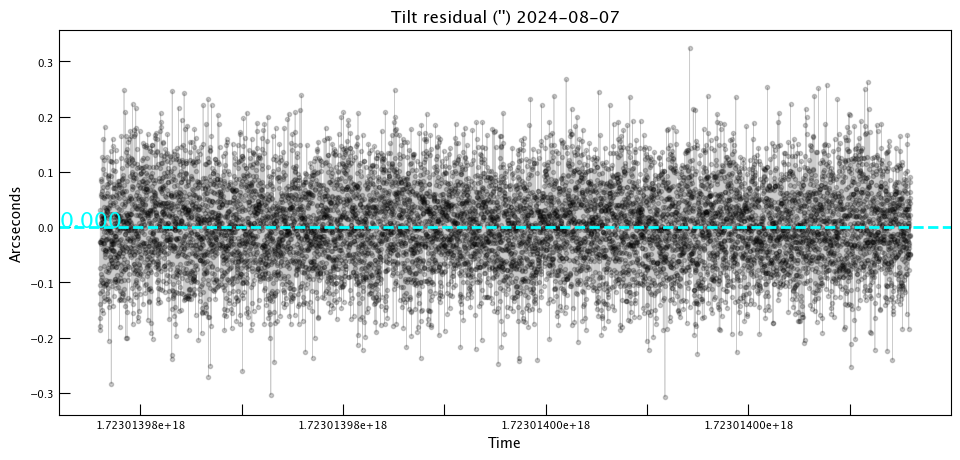

In [44]:
plt.figure(figsize=(10.0, 5.0))
plt.plot(strap_telemetry['rawtimestamp'], tilt_centroids, 'k.-', linewidth=0.5, alpha=0.2)
plt.axhline(y=np.mean(tilt_centroids), color='cyan', linestyle='--', linewidth=2, 
            label=r"$\bar{\mathtt{residual tilt}}$ arcsec")
plt.text(plt.xlim()[0], np.mean(tilt_centroids)*1.03, s=f"{np.mean(tilt_centroids):.3f}", color='cyan')
plt.title("Tilt residual (\'\') 2024-08-07", fontsize=12.0)
plt.gca().xaxis.set_major_formatter(FuncFormatter(sci_format))
plt.ylabel("Arcseconds", fontsize=10.0)
for label in plt.gca().xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xlabel("Time", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")

##### **Fourier analysis of tip/tilt residuals**

In [45]:
def linspace(start, stop, step=1.):
  """
    Like np.linspace but uses step instead of num
    This is inclusive to stop, so if start=1, stop=3, step=0.5
    Output is: array([1., 1.5, 2., 2.5, 3.])
  """
  return np.linspace(start, stop, int((stop - start) / step + 1), endpoint=True)

In [46]:
fs = 1000
t = linspace(0, 1-(1/fs), step=1/fs)
x = np.cos(2*np.pi*100.0*t) + np.random.randn(len(t))
print(len(t))

1000


In [47]:
N = len(x)
xdft = np.fft.fft(x)
xdft = xdft[0:int(N/2)+1]
psdx = (1/(fs*N)) * np.abs(xdft)**2.0
psdx[1:N-1] = 2*psdx[1:N-1]
freq = linspace(0, fs/2, step=fs/len(x))

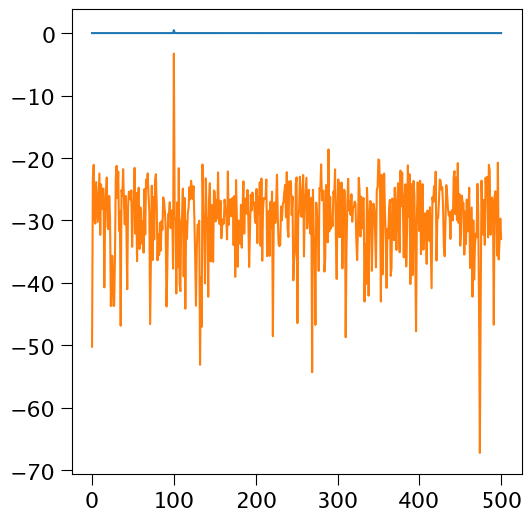

In [48]:
db_value = 10.0 * np.log10(psdx)
plt.plot(freq, psdx)
plt.plot(freq, db_value)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


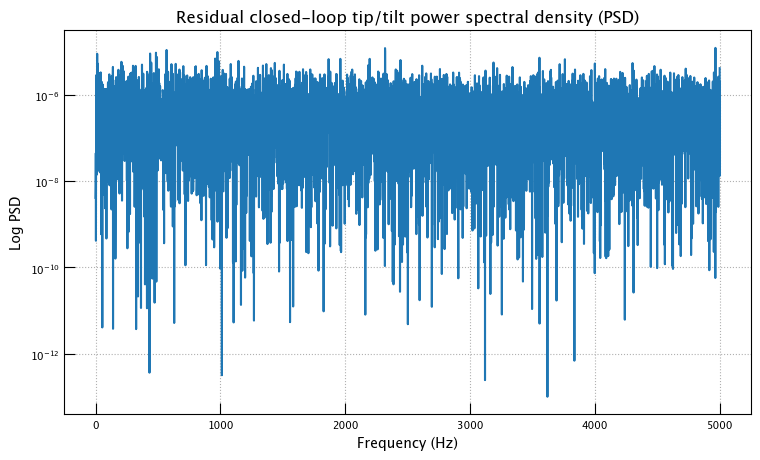

In [49]:
N = len(tip_centroids)
tip_dft = np.fft.fft(tip_centroids)
tip_dft = tip_dft[0:int(N/2)+1]
psdx = (1/(N*N)) * (tip_dft.real)**2.0
psdx[0:N-1] = 2*psdx[0:N-1]
freq = linspace(0, N/2, step=N/len(tip_centroids))

# PSD & Welch plots
plt.figure(figsize=(8.0, 5.0))
plt.semilogy(freq, psdx)
plt.title("Residual closed-loop tip/tilt power spectral density (PSD)", fontsize=12.0)
plt.ylabel("Log PSD", fontsize=10.0)
plt.xlabel("Frequency (Hz)", fontsize=10.0)
plt.legend(ncol=2, fontsize=9.0, frameon=False)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")
plt.grid(True, linestyle='dotted')

In [50]:
# Fourier transforms
N = len(tip_centroids)
dt = np.mean(np.diff(strap_telemetry['rawtimestamp']))*(1.0e-9)
x_freq, x_tt_fft = mu.tt_fft(tip_centroids, delta_t=dt) # delta_t in sec
y_freq, y_tt_fft = mu.tt_fft(tilt_centroids, delta_t=dt) # delta_t in sec
# Average X and Y spectra together to reduce noise, overlay on plot
mean_fft = np.mean([x_tt_fft, y_tt_fft], axis=0)
freq = x_freq
# Put this averaged FFT into noise reduction to further reduce noise
# Savitzky-Golay filter
mean_fft_filtered=mu.Savitzky_Golay(mean_fft, 5, 2)
# Convert FFT result to power spectral density (PSD)
psd_fft = np.square(np.abs(mean_fft)) / (2*(1.0/2*dt))
psd_fft_filt = np.square(np.abs(mean_fft_filtered)) / (2*(1.0/dt))
# Welch's method for PSD direct from timestream signal (TT centroids)
f, pxx_den_x = signal.welch(tip_centroids, nperseg=250, fs=(1/dt), scaling='density')
_, pxx_den_y = signal.welch(tilt_centroids, nperseg=250, fs=(1/dt), scaling='density')
pxx_den_avg = np.mean( np.array([ pxx_den_x, pxx_den_y ]), axis=0 )
pxx_den_sg = mu.Savitzky_Golay(pxx_den_avg, 10, 2)

/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/signal/_savitzky_golay.py:339: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(np.float64)


(array([4.58846444e-05, 6.66704907e-05, 4.35357005e-05, 4.36143464e-05,
        5.73391885e-05, 9.05563377e-05, 1.18569144e-04, 9.83041762e-05,
        8.96320211e-05, 6.34125333e-05, 4.33138773e-05, 5.70109257e-05,
        9.48702895e-05, 6.83584640e-05, 5.79669756e-05, 6.65339209e-05,
        6.23705101e-05, 6.22683718e-05, 5.78133626e-05, 5.15645549e-05,
        5.97736452e-05, 6.44936978e-05, 5.27997055e-05, 4.20957170e-05,
        5.03562416e-05, 5.09297561e-05, 4.82838572e-05, 4.83648000e-05,
        4.87808054e-05, 4.69483580e-05, 4.32309152e-05, 4.30165807e-05,
        4.41028899e-05, 5.48752645e-05, 5.62977748e-05, 5.46242947e-05,
        7.28733011e-05, 6.88788307e-05, 4.14893005e-05, 4.06889178e-05,
        5.38309417e-05, 5.93385562e-05, 5.09842467e-05, 4.83115441e-05,
        5.80506832e-05, 5.56847113e-05, 4.68913543e-05, 5.32571711e-05,
        6.24126171e-05, 5.61785402e-05, 5.48871619e-05, 4.37684621e-05,
        4.37168466e-05, 5.31156156e-05, 3.80759738e-05, 3.982709

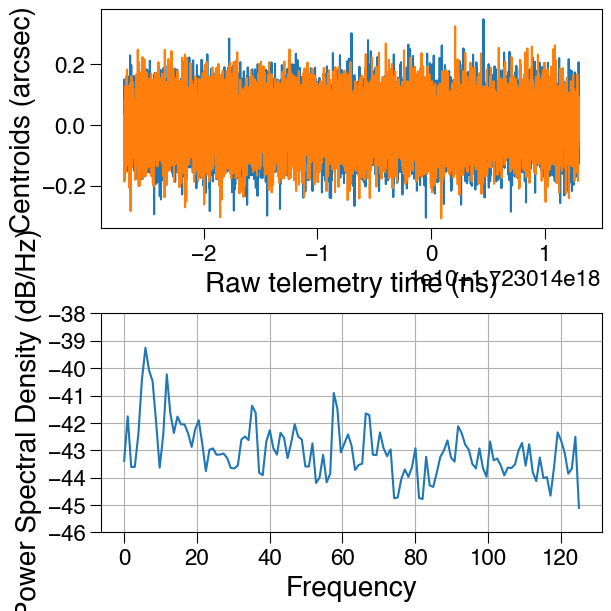

In [51]:
fig, (ax0, ax1) = plt.subplots(2, 1, layout='constrained')
ax0.plot(strap_telemetry['rawtimestamp'], tip_centroids, label="tip")
ax0.plot(strap_telemetry['rawtimestamp'], tilt_centroids, label="tilt")
ax0.set_xlabel('Raw telemetry time (ns)')
ax0.set_ylabel('Centroids (arcsec)')
ax1.psd(tip_centroids, Fs=1/dt)

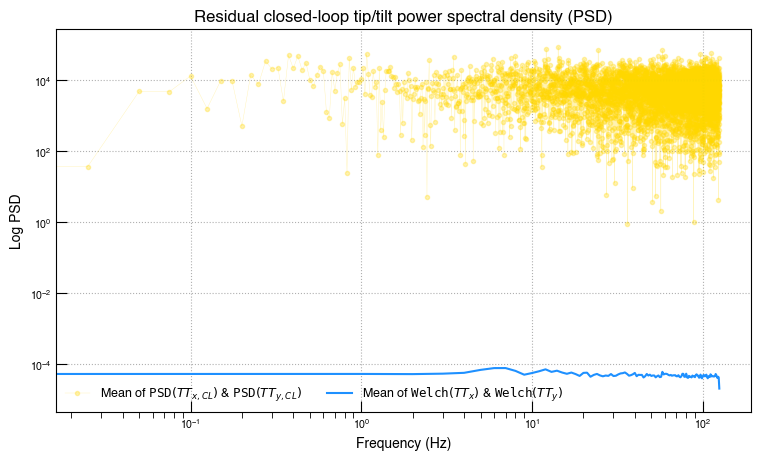

In [52]:
# PSD & Welch plots
plt.figure(figsize=(8.0, 5.0))
plt.loglog(freq, psd_fft, '.-', linewidth=0.3, color="gold", alpha=0.3,
             label="Mean of $\mathtt{PSD}(TT_{x, CL})$ & $\mathtt{PSD}(TT_{y, CL})$")
# plt.semilogy(freq, psd_fft_filt, '.-', linewidth=0.5, color="violet", 
#              label="Savitzsky-Golay-filtered PSD", alpha=0.3)
plt.title("Residual closed-loop tip/tilt power spectral density (PSD)", fontsize=12.0)
plt.ylabel("Log PSD", fontsize=10.0)
plt.xlabel("Frequency (Hz)", fontsize=10.0)
plt.semilogy(f, pxx_den_avg, color="dodgerblue", 
             label="Mean of $\mathtt{Welch}(TT_{x})$ & $\mathtt{Welch}(TT_{y})$")
# plt.semilogy(f, pxx_den_sg, color="blue", 
#              label="SG(Welch PSD)")
plt.legend(ncol=2, fontsize=9.0, frameon=False)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")
plt.grid(True, linestyle='dotted')

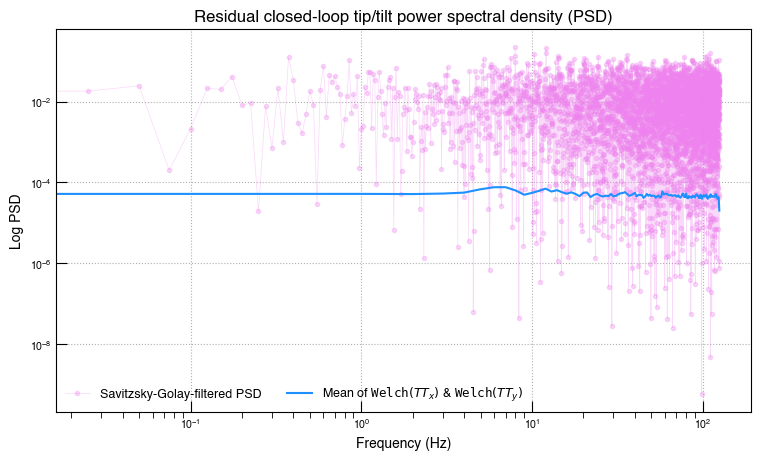

In [53]:
# PSD & Welch plots
plt.figure(figsize=(8.0, 5.0))
# plt.semilogy(freq, psd_fft, '.-', linewidth=0.3, color="gold", alpha=0.3,
#              label="Mean of $\mathtt{PSD}(TT_{x, CL})$ & $\mathtt{PSD}(TT_{y, CL})$")
plt.loglog(freq, psd_fft_filt, '.-', linewidth=0.5, color="violet", 
             label="Savitzsky-Golay-filtered PSD", alpha=0.3)
plt.title("Residual closed-loop tip/tilt power spectral density (PSD)", fontsize=12.0)
plt.ylabel("Log PSD", fontsize=10.0)
plt.xlabel("Frequency (Hz)", fontsize=10.0)
plt.semilogy(f, pxx_den_avg, color="dodgerblue", 
             label="Mean of $\mathtt{Welch}(TT_{x})$ & $\mathtt{Welch}(TT_{y})$")
# plt.semilogy(f, pxx_den_sg, color="blue", 
#              label="SG(Welch PSD)")
plt.legend(ncol=2, fontsize=9.0, frameon=False)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")
plt.grid(True, linestyle='dotted')

#### **Examine subapertures and actuators**

In [54]:
# From pyAO repo: https://github.com/KeckObservatory/PyAO/blob/81e7fce4e699dfafd12c8cbcacf523c262bab5c2/aoscripts/PyWFS/pwfsTools.py#L700

# Function to select actuators using the measured pupil from the WFS and
# applying this to the IM. The signal for each actuator is then computed and
# compared with the full pupil signal - actuators which fall below a given
# threhold are set as 'badly seen'
# 30th October 2022
def actuatorSelection2(IM, wfsMask, pup_wfs, pup_dm, calibType):
    if calibType == 'zernike':
        z2p = pf.getdata(configDir + dmId + 'zbasis.fits')[:, pup_dm == 1]
        # Convert to zonal IM
        IM = np.matmul(IM, z2p)
    elif calibType == 'fourier':
        f2p = pf.getdata(configDir + dmId + 'fbasis.fits')[:, pup_dm == 1]
        # Convert to zonal IM
        IM = np.matmul(IM, f2p)

    # Combined signal from Sx and Sy for each actuator
    nPx = int(np.shape(IM)[0] / 2)
    IM_amp = np.sqrt(IM[0:nPx, :] ** 2 + IM[nPx:2 * nPx, :] ** 2)

    # Energy for each actuator (current illumination compared to full pupil)
    energy_act = np.sum(np.array([wfsMask[pup_wfs == 1]]).T * IM_amp, 0) / np.sum(IM_amp, 0)

    # Actuator energy threshold
    dmThres = 0.7

    dmvec = 0 * energy_act
    dmvec[energy_act > dmThres] = 1

    return dmvec

# is pupil mask of below function related to pupil masks above?
def compute_pupil_mask_v2(array_size, pupil_diameter, offset_x=0, offset_y=0):
    """Compute pupil mask for given pupil diameter.

    :param integer pupil_diameter: Diameter of pupil.
    :param integer array_size: Size of array
    :return: Pupil binary mask.
    :rtype: numpy.ndarray
    """
    # Create the pupil mask (initialy array of zeros).
    pupil_mask = np.zeros([array_size, array_size])
    #
    radius = pupil_diameter / 2
    # Compute the 1d ramp needed to compute the 2d ramps.
    ramp_1d = np.linspace(-(array_size - 1) / 2, (array_size - 1) / 2, array_size)
    # Compute the 2d ramps needed to compute the radial ramp.
    [ramp_2d_x, ramp_2d_y] = np.meshgrid(ramp_1d + offset_x, ramp_1d + offset_y)
    # Compute the radial ramp.
    radial_ramp = np.sqrt(pow(ramp_2d_x, 2) + pow(ramp_2d_y, 2))
    # For each element of the pupil mask, if its distance to the center is <= to the radius, set its value to 1.
    pupil_mask[radial_ramp <= radius] = 1
    # Return the pupil mask.
    return pupil_mask

#### **LGSWFS**

##### *SNR*

Following KAON 422 equations

In [63]:
# Centroid errors/residuals in arcseconds for SHWFS
shwfs_centroids = ocam2k_telemetry['SHWFS1Centroid']
# Standard deviation across all subapertures -- change this to restrict to certain subapertures if SNR calculation needs to be fine-tuned
sigma_all_subap = np.std(np.abs(shwfs_centroids), axis=1)
# SNR = theta (spot size) / sigma_arcsec
# Spot size in arcseconds - try 1.5'' for known LGS spot size
spot = 1.5
SNR_KAON422 = spot / sigma_all_subap

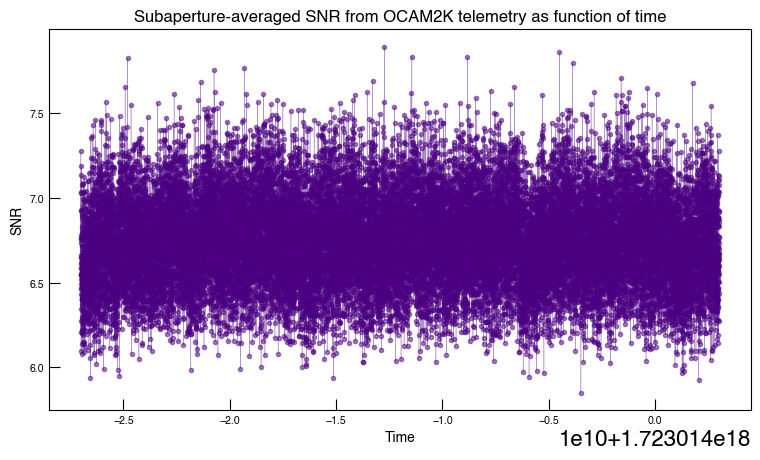

In [64]:
plt.figure(figsize=(8.0, 5.0))
plt.plot(ocam2k_telemetry['rawtimestamp'], SNR_KAON422, '.-', linewidth=0.3, alpha=0.5, color="indigo")
plt.title("Subaperture-averaged SNR from OCAM2K telemetry as function of time", fontsize=12.0)
plt.ylabel("SNR", fontsize=10.0)
plt.xlabel("Time", fontsize=10.0)
plt.xticks(fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.gca().tick_params(axis="y", direction="in")
plt.gca().tick_params(axis="x", direction="in")
plt.show()

In [57]:
print(f"SNR calculated from telemetry centroid error standard deviation (subaperture averaged and time averaged) = {np.mean(SNR_KAON422)}")

SNR calculated from telemetry centroid error standard deviation (subaperture averaged and time averaged) = 6.745968971488814


In [66]:
# Centroid errors/residuals in arcseconds for SHWFS
shwfs_centroids_x = ocam2k_telemetry['SHWFS1Centroid'][:,::2]
shwfs_centroids_y = ocam2k_telemetry['SHWFS1Centroid'][:,1::2]
# Standard deviation across all subapertures -- change this to restrict to certain subapertures if SNR calculation needs to be fine-tuned
sigma_by_subap = np.std(np.abs(shwfs_centroids_x), axis=0)
# SNR = theta (spot size) / sigma_arcsec
# Spot size in arcseconds - try 1.5'' -> 1.93 '' (KAON 1317) for known LGS spot size
spot = 1.93
SNR_KAON422_timeavg = spot / sigma_by_subap

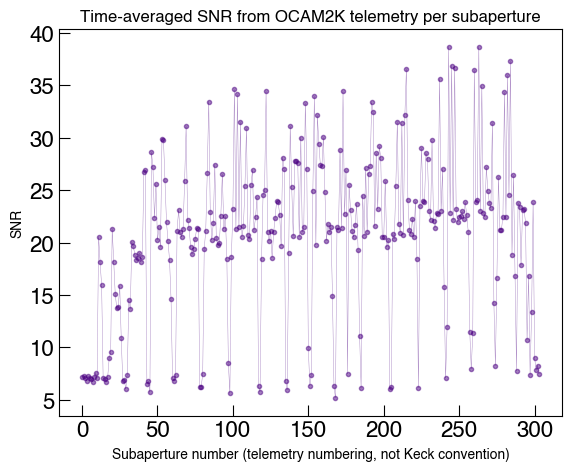

In [67]:
fig, axes = plt.subplots(figsize=(6.0, 5.0))
plt.plot(SNR_KAON422_timeavg, '.-', linewidth=0.3, alpha=0.5, color="indigo")
plt.title("Time-averaged SNR from OCAM2K telemetry per subaperture", fontsize=12.0)
# plt.ylim(0.0, 0.7)
# plt.xlim(0.0, 0.7)
xlim = plt.gca().get_xlim()
plt.gca().tick_params(axis='both', direction='in')
plt.ylabel("SNR", fontsize=10.0)
plt.xlabel("Subaperture number (telemetry numbering, not Keck convention)", fontsize=10.0)
plt.tight_layout()
# plt.legend(ncol=1, frameon=False, fontsize="11")
# plt.savefig('/Users/bdigia/work/ao/strehl_plot_20241113_final.png', dpi=fig.dpi)
plt.show()

In [68]:
np.mean(SNR_KAON422_timeavg[SNR_KAON422_timeavg > 20])

25.07271651352803

In [69]:
len(SNR_KAON422_timeavg[SNR_KAON422_timeavg > 20])

199

The less illuminated subapertures bring down the SNR subaperture-average considerably. Looking at the group of reliably illuminated subapertures $> 15$ SNR (likely type 1), it looks like the time-averaged SNR for this night of telemetry was $\sim 20$ 

In [70]:
# compare to keck_nea_photons prediction

# LGSWFS parameters (OCAM2K, not CCD39)
band = "R" # not actually at V-band
side = 0.563
ps = 3.0
sigma_e = 6.5
theta_beta = 1.5 * ( np.pi/180.0 ) / ( 60.0*60.0 )
throughput = 0.36
pix_per_ap = 4
# Use integration time from telemetry timestamp interval
time = np.mean(np.diff(ocam2k_telemetry['rawtimestamp']))*(1e-9) # seconds
# Need magnitude of star used in telemetry
m = 8.1

Np, Nb = mu.n_photons(side, time, m, band, ps, throughput)
print(Np, Nb)
SNR = Np / np.sqrt(Np + pix_per_ap*Nb + pix_per_ap*sigma_e**2)
SNR

682.2601586023783 0.0809454646373532


23.379557091255958